102.26666666666667
50.63333333333333
[   82.41203408   225.54366641   549.87232259   771.29396024
   878.03082257  1253.18446724  4507.68409013  4938.81271647
  5318.44228845  5461.9142049   6719.40424715 12210.73534012
 14502.5083029  16867.9605037  16875.25777198]


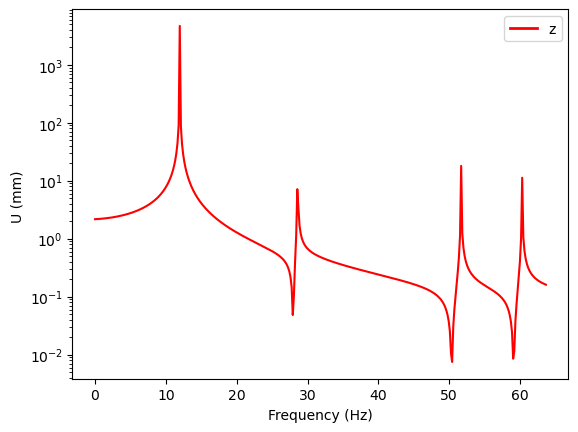

In [6]:
eimport math
import numpy as np
import scipy
import matplotlib.pyplot as plt
from Scripts.drone_mass import DroneMass
from Scripts.drone_battery import Battery
from Scripts.drone_geometry import DroneGeometry
from Scripts.beams import BeamType
from Scripts.mission_profile import MissionProfile
from Scripts.drone_power import DronePower
from Scripts.drone_power import BatterySystem
from Scripts.drone_forces import DroneForces
from Scripts.drone_fea import DroneFEA
import Scripts.unit_conversions as uc
import Scripts.visualization as vis
from scipy.optimize import NonlinearConstraint
from matplotlib.lines import Line2D

drag_coeff = 0.256

stress_FOS = 3
power_FOS = 1.25

allowable_deflection = 50.0 # mm

# https://store.tmotor.com/product/u8lite-l-kv95-u-efficiency.html
# Propeller Max RPM for 32in Propeller
Propeller_RPM = 3068
Propeller_Forcing_Function_Hz = Propeller_RPM / 30
Propeller_RPM_min = 1519
Propeller_Forcing_Function_Hz_min = Propeller_RPM_min / 30

print(Propeller_Forcing_Function_Hz)
print(Propeller_Forcing_Function_Hz_min)

Propeller_radius = 406.4
# spacing between propellers
Propeller_spacing = 25
arm_length = (Propeller_spacing + Propeller_radius) / math.sin(22.5 * math.pi/180)

# Battery geometry
battery_1 = Battery(4.292e-3, np.array([0, 86.75, -50]), np.array([260.5, 123.5, 63.5]))
battery_2 = Battery(4.292e-3, np.array([0, -86.75, -50]), np.array([260.5, 123.5, 63.5]))

# Mission profile generation
mission_profile = MissionProfile("m1", 1, 0, 0)
mission_profile.add_segment("takeoff",2,0,2,0,1)
mission_profile.add_segment("climb",15,550000,100000,300,0)
mission_profile.add_segment("cruise",50,2000000,110000,300,0)
mission_profile.add_segment("descent",10,2200000,50000,0,0)
mission_profile.add_segment("loiter",5,2200000,50000,0,0)
mission_profile.add_segment("land",10,2400000,0,0,0)

# Drone Power Analysis
battery_sys = BatterySystem("Tattu 40000mAh 6S 10C 22.8V High Voltage UAV Lipo Battery Pack with AS150+AS150", 22.8, 40000, 2)

arm_length = (Propeller_spacing + Propeller_radius) / math.sin(22.5 * math.pi/180)

arm_d1,arm_t,strut_d1,strut_t,strut_dist = np.array([15.0,2.5,24.0,2.0,500.0])

arm_beam_properties = BeamType("annulus", [arm_d1 + arm_t*2, arm_d1 ], "Carbon Fiber", "arm_beam")
strut_beam_properties = BeamType("annulus", [strut_d1 + strut_t*2, strut_d1 ], "Carbon Fiber", "strut_beam")

drone_geometry = DroneGeometry("drone", arm_length, strut_dist, 8, arm_beam_properties, strut_beam_properties, [battery_1, battery_2])

d1_fea = DroneFEA(drone_geometry)
d1_fea.create_drone_slice_nodes() # nominal radius | strut rad | number of blades
d1_fea.create_drone_slice_beams() # arm beam | strut beam
d1_fea.boundary_conditions_slice()
d1_fea.beam_system.add_force(np.array([0,0,1]),"outer_node")
d1_fea.beam_system.add_dynamic_force(np.array([0,0,1,0,0,0]),0,0,"outer_node")
d1_fea.solve_fea()
d1_fea.solve_natural_frequencies()

Frequencies = np.linspace(0, 400, 400)
UperF_z = np.zeros(len(Frequencies))
UperF_y = np.zeros(len(Frequencies))

print(d1_fea.beam_system.natural_frequencies)
UperF_mag = np.zeros(len(Frequencies))
for i, freq in enumerate(Frequencies):
    d1_fea.beam_system.nodes[d1_fea.beam_system.select_node("outer_node")].dynamic_forces_frequency[0] = freq # update freq
    d1_fea.solve_dynamic(1.6,0.002)
    UperF_z[i] = abs(d1_fea.beam_system.z_displacements_amplitude[0][2])
    UperF_y[i] = abs(d1_fea.beam_system.y_displacements_amplitude[0][2])

plt.plot(Frequencies  * uc.rad_per_s_to_Hz, UperF_z, color='r')
plt.plot(Frequencies * uc.rad_per_s_to_Hz, UperF_y, color='g')
plt.yscale('log')
plt.xlabel("Frequency (Hz)")
plt.ylabel("U (mm) ")


legend_elements = [
    Line2D([0], [0], color='r', lw=2, label='z'),
]

plt.legend(handles=legend_elements, loc='upper right')

[113.31363509]
0.0 | 1.6448386838583249
3.076923076923077 | 1.647699327747268
6.153846153846154 | 1.6530161092293092
9.230769230769232 | 1.6608366676127624
12.307692307692308 | 1.6712319157870168
15.384615384615385 | 1.6842976693737464
18.461538461538463 | 1.7001569000496226
21.53846153846154 | 1.7189627140949808
24.615384615384617 | 1.740902194819095
27.692307692307693 | 1.7662012957867617
30.76923076923077 | 1.7951310351947416
33.84615384615385 | 1.8280153266556278
36.92307692307693 | 1.865240897189055
40.0 | 1.9072699028319489
43.07692307692308 | 1.9546560760214777
46.15384615384615 | 2.0080655572306374
49.23076923076923 | 2.068304023290763
52.307692307692314 | 2.1363524004510492
55.38461538461539 | 2.2134144603691275
58.46153846153847 | 2.3009811369636144
61.53846153846154 | 2.4009187992526475
64.61538461538461 | 2.515592535763662
67.6923076923077 | 2.6480417553018607
70.76923076923077 | 2.8022359329773634
73.84615384615385 | 2.9834566461986074
76.92307692307693 | 3.198885137271288

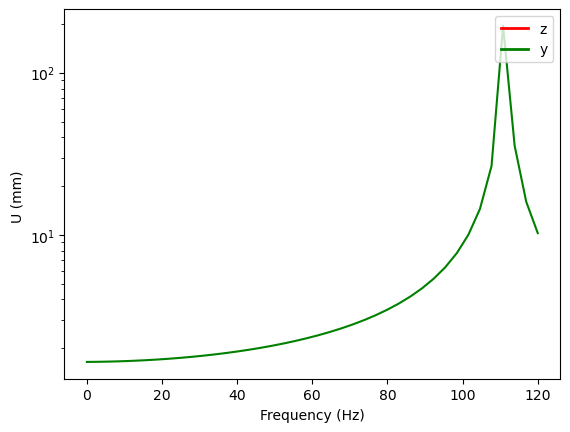

In [32]:
import math
import numpy as np
import scipy
import matplotlib.pyplot as plt
from Scripts.drone_mass import DroneMass
from Scripts.drone_battery import Battery
from Scripts.drone_geometry import DroneGeometry
from Scripts.beams import BeamSystem
from Scripts.beams import BeamType
from Scripts.mission_profile import MissionProfile
from Scripts.drone_power import DronePower
from Scripts.drone_power import BatterySystem
from Scripts.drone_forces import DroneForces
from Scripts.drone_fea import DroneFEA
import Scripts.unit_conversions as uc
import Scripts.visualization as vis
from scipy.optimize import NonlinearConstraint
from matplotlib.lines import Line2D


arm_beam_properties = BeamType("annulus", [18,15], "Carbon Fiber", "arm_beam")

beam_sys = BeamSystem("Cantilever")
beam_sys.add_node(np.array([0,0,0]),"origin")
beam_sys.add_node(np.array([1000,0,0]),"endpoint")
beam_sys.add_beam(arm_beam_properties,"origin","endpoint",np.array([0,1,0]),"cantilever")
beam_sys.add_boundary_condition(0,"en castre","origin")
beam_sys.add_boundary_condition(0,"x","endpoint")
beam_sys.add_boundary_condition(0,"z","endpoint")
beam_sys.add_boundary_condition(0,"theta x","endpoint")
beam_sys.add_boundary_condition(0,"theta y","endpoint")
beam_sys.add_boundary_condition(0,"theta z","endpoint")
beam_sys.add_force(np.array([0,-1,0]),"endpoint")
beam_sys.add_dynamic_force(np.array([0,1,0,0,0,0]),0,0,"endpoint")
beam_sys.solve_FEA()
beam_sys.solve_static()
beam_sys.solve_dynamic(6,0.002)
beam_sys.solve_natural_frequencies()
print(beam_sys.natural_frequencies)


Frequencies = np.linspace(0, 120, 40)
UperF_z = np.zeros(len(Frequencies))
UperF_y = np.zeros(len(Frequencies))

for i, freq in enumerate(Frequencies):
    end_node = beam_sys.select_node("endpoint")
    beam_sys.nodes[end_node].dynamic_forces_frequency[0] = freq # update freq
    beam_sys.solve_dynamic(1.6,0.0002)
    print(freq,"|",beam_sys.y_displacements_amplitude[0][end_node])
    UperF_z[i] = abs(beam_sys.z_displacements_amplitude[0][end_node])
    UperF_y[i] = abs(beam_sys.y_displacements_amplitude[0][end_node])

plt.plot(Frequencies, UperF_z, color='r')
plt.plot(Frequencies, UperF_y, color='g')
plt.yscale('log')
plt.xlabel("Frequency (Hz)")
plt.ylabel("U (mm) ")
print("Static: ",beam_sys.y_displacements)

legend_elements = [
    Line2D([0], [0], color='r', lw=2, label='z'),
    Line2D([0], [0], color='g', lw=2, label='y'),
]

plt.legend(handles=legend_elements, loc='upper right')
